/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9291 - loss: 0.2449
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9680 - loss: 0.1028
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9776 - loss: 0.0712
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9828 - loss: 0.0539
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9868 - loss: 0.0425
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9774 - loss: 0.0818
Accuracy: 0.977400004863739
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
[[ 969    0    1    1    1    0    2    2    0    4]
 [   0 1128    2    1    0    0    1    0    3    0]
 [   2    0 1017    2    0    0    1    8    2    0]
 [   0    0    6  992    0    0    0    6    1    5]
 [   0    0    6    0  971    0    3    1    0    1]
 [   2    0    0   17    0  859    5    1    4    4]
 [   5    3    2    1    7    1  938    0    1    0]
 [   0    1   11    0    0    0    0 1014    0   

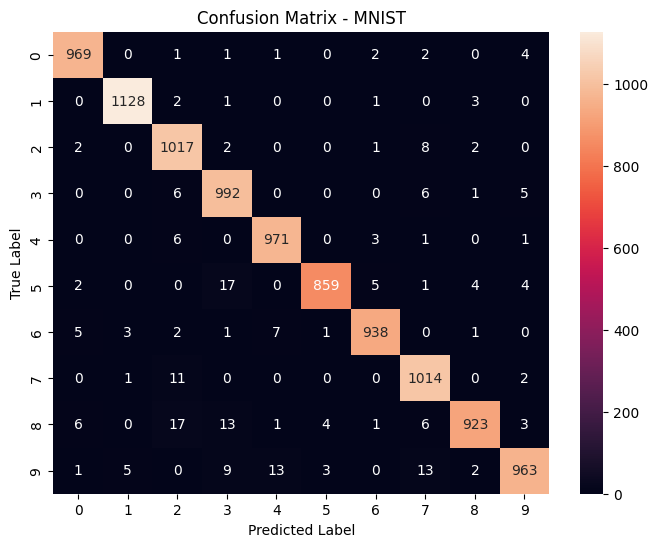

In [5]:
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense
from keras.utils import to_categorical
from sklearn.metrics import confusion_matrix

# Load Data
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Flatten
X_train = X_train.reshape(60000, 784) / 255
X_test = X_test.reshape(10000, 784) / 255

y_train = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

# Model
model = Sequential()
model.add(Dense(128, input_dim=784, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train
model.fit(X_train, y_train, epochs=5)

# Evaluate
loss, acc = model.evaluate(X_test, y_test_cat)
print("Accuracy:", acc)

# Confusion Matrix
pred = model.predict(X_test)
pred_classes = pred.argmax(axis=1)

print(confusion_matrix(y_test, pred_classes))
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate confusion matrix
cm = confusion_matrix(y_test, pred_classes)

# Plot
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - MNIST")
plt.show()